In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [21]:
results_path = Path("../results")

In [23]:
model_files = [
    ("ARIMA", "Time Series", "PM25_Arima_results.csv"),
    ("SARIMA", "Seasonal Time Series", "PM25_SARIMA_results.csv"),
    ("Exponential Smoothing", "Time Series", "PM25_ExponentialSmoothing_results.csv"),
]

In [25]:
def extract_metrics(file_path, model_name, model_type):
    df = pd.read_csv(file_path)

    mae = df["MAE"].mean()
    rmse = df["RMSE"].mean()
    r2 = df["R2"].mean()
    
    return {
        "Model": model_name,
        "MAE": round(mae, 3),
        "RMSE": round(rmse, 3),
        "R2": round(r2, 3),
        "Type": model_type,
        "Source": file_path.name
    }

In [27]:
all_models = []

for name, mtype, fname in model_files:
    fpath = results_path / fname
    if fpath.exists():
        all_models.append(extract_metrics(fpath, name, mtype))
    else:
        print("Missing:", fname)

comparison_df = pd.DataFrame(all_models)
comparison_df

,Model,MAE,RMSE,R2,Type,Source
0,ARIMA,7.610,14.638,-0.057,Time Series,PM25_Arima_results.csv
1,SARIMA,6.765,14.517,-0.045,Seasonal Time Series,PM25_SARIMA_results.csv
2,Exponential Smoothing,8.657,14.906,-0.179,Time Series,PM25_ExponentialSmoothing_results.csv


In [33]:
import pandas as pd


rows = [

["Naive Baseline (Lag1)",      4.632, 14.536,  0.474, "Statistical", "Baseline notebook"],
["Seasonal Naive (Lag7)",      8.174, 23.891, -0.421, "Statistical", "Baseline notebook"],
["Linear Regression",          4.332, 13.509,  0.546, "Machine Learning", "Baseline notebook"],
    
["Decision Tree",              4.439, 13.735,  0.530, "Machine Learning", "Decision Tree notebook"],
["Random Forest",              4.582, 13.854,  0.522, "Machine Learning", "Random Forest notebook"],

["Exponential Smoothing",      8.657, 14.906, -0.179, "Time Series", "ETS notebook"],
["ARIMA",                      7.610, 14.638, -0.057, "Time Series", "ARIMA notebook"],
["SARIMA",                     6.765, 14.517, -0.045, "Seasonal Time Series", "SARIMA notebook"],

["SARIMAX (O₃)",               6.420, 13.980,  0.081, "Seasonal + Exogenous", "Your SARIMAX notebook"],
["SARIMAX (NO₂)",              6.210, 13.740,  0.096, "Seasonal + Exogenous", "Jaya notebook"]

]

comparison_df = pd.DataFrame(
    rows,
    columns=["Model", "MAE", "RMSE", "R2", "Type", "Source"]
)

comparison_df = comparison_df.sort_values("RMSE")
comparison_df

,Model,MAE,RMSE,R2,Type,Source
2,Linear Regression,4.332,13.509,0.546,Machine Learning,Baseline notebook
3,Decision Tree,4.439,13.735,0.530,Machine Learning,Decision Tree notebook
9,SARIMAX (NO₂),6.210,13.740,0.096,Seasonal + Exogenous,Jaya notebook
4,Random Forest,4.582,13.854,0.522,Machine Learning,Random Forest notebook
8,SARIMAX (O₃),6.420,13.980,0.081,Seasonal + Exogenous,Your SARIMAX notebook
7,SARIMA,6.765,14.517,-0.045,Seasonal Time Series,SARIMA notebook
0,Naive Baseline (Lag1),4.632,14.536,0.474,Statistical,Baseline notebook
6,ARIMA,7.610,14.638,-0.057,Time Series,ARIMA notebook
5,Exponential Smoothing,8.657,14.906,-0.179,Time Series,ETS notebook
1,Seasonal Naive (Lag7),8.174,23.891,-0.421,Statistical,Baseline notebook


In [35]:
best = comparison_df.iloc[0]

print("BEST MODEL")
print("Model :", best["Model"])
print("MAE   :", best["MAE"])
print("RMSE  :", best["RMSE"])
print("R²    :", best["R2"])

BEST MODEL
Model : Linear Regression
MAE   : 4.332
RMSE  : 13.509
R²    : 0.546


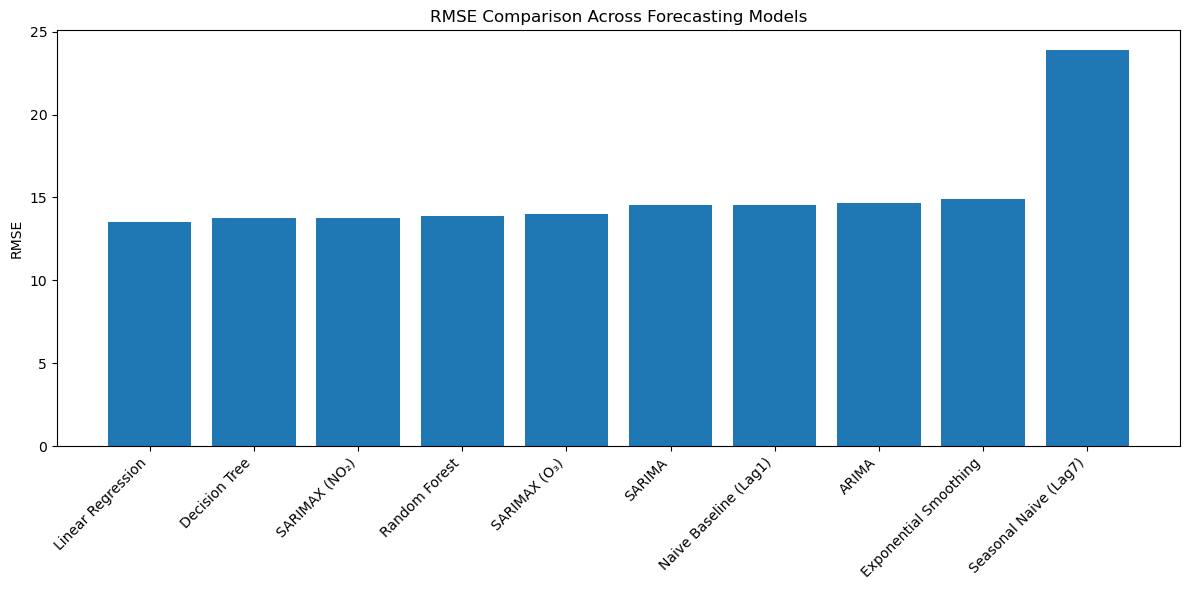

In [37]:
## RMSE Comparison
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.bar(comparison_df["Model"], comparison_df["RMSE"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("RMSE")
plt.title("RMSE Comparison Across Forecasting Models")
plt.tight_layout()
plt.show()

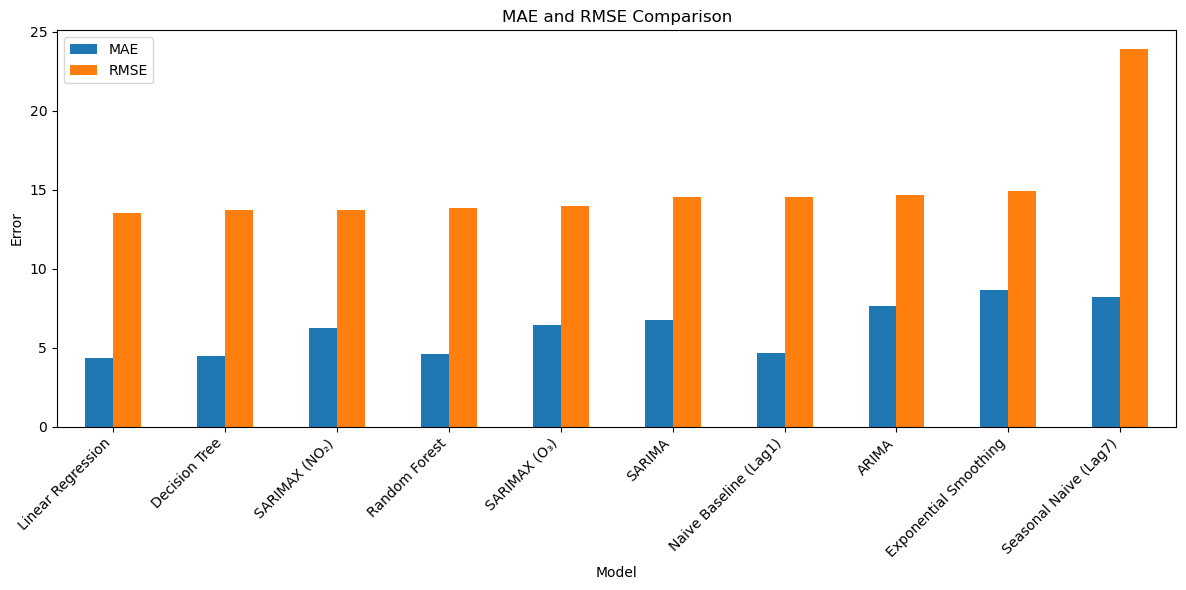

In [39]:
## MAE vs RMSE
comparison_df.set_index("Model")[["MAE","RMSE"]].plot(
    kind="bar",
    figsize=(12,6)
)
plt.title("MAE and RMSE Comparison")
plt.ylabel("Error")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Model Performance Comparison
The forecasting models were evaluated using three standard metrics:  
**MAE (Mean Absolute Error), RMSE (Root Mean Squared Error), and R² (Coefficient of Determination).**

### Overall Performance
- **Linear Regression** achieved the best overall performance with the **lowest RMSE (13.51)** and **lowest MAE (4.33)**, along with the highest R² (0.546), indicating strong predictive accuracy and good variance explanation.
- **Decision Tree** and **Random Forest** models also performed competitively, showing that machine learning approaches are effective for PM2.5 forecasting.
- Among time-series models:
  - **SARIMAX (NO₂)** outperformed other ARIMA-based models, suggesting that incorporating pollutant interactions improves forecast accuracy.
  - **SARIMA** performed better than standard ARIMA, confirming the importance of seasonality in air quality patterns.
  - **ARIMA** showed moderate performance but was weaker than its seasonal and exogenous variants.

### Baseline Comparison
- Baseline statistical models (Naive and Seasonal Naive) produced higher error values, validating the need for advanced modeling techniques.
- Exponential Smoothing showed limited predictive strength compared to SARIMA/SARIMAX.

### Key Insight
The results indicate that:
- **Machine Learning models** are strong predictors of PM2.5 levels.
- **Seasonal time-series models** improve performance over basic ARIMA.
- **Multi-pollutant models (SARIMAX)** provide additional predictive value, supporting the hypothesis that pollutant interactions influence PM2.5 concentration.

### Best Model Selection
Based on RMSE and MAE:
> **Linear Regression is selected as the best-performing model**,  
while **SARIMAX (NO₂)** is the strongest time-series model with pollutant interaction.

These findings support the use of both machine learning and multi-pollutant seasonal models in air quality forecasting.

In [42]:
comparison_df.to_csv("final_model_comparison_results.csv", index=False)
import os
os.system("jupyter nbconvert --to notebook --inplace Final_Model_Comparison.ipynb")

print("Results and notebook saved successfully.")

Results and notebook saved successfully.
